<a href="https://colab.research.google.com/github/mail2gokulakrishnan-commits/GOKUL-s-CAPSTONE-projects/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
%cd /content/drive/MyDrive/Assignment 2/

/content/drive/MyDrive/Assignment 2


In [7]:
# Task 2: Load the Dataset

df = pd.read_csv("cleaned_data.csv")

# Display first 5 rows
print(df.head())

# Dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

   Row ID        Order ID  Order Date       Ship Mode      Segment Region  \
0       1  CA-2026-100000  2024-01-01     First Class    Corporate  South   
1       2  CA-2026-100001  2024-01-02        Same Day  Home Office   West   
2       3  CA-2026-100002  2024-01-03  Standard Class     Consumer   West   
3       4  CA-2026-100003  2024-01-04     First Class     Consumer   West   
4       5  CA-2026-100004  2024-01-05     First Class     Consumer   East   

          Category       Sales  Quantity  Discount      Profit  
0  Office Supplies   50.141956         9       0.5         NaN  
1        Furniture  128.521772        12       0.0  185.361727  
2       Technology  332.204020        12       0.2   33.988723  
3       Technology  539.816053         2       0.0  119.611821  
4  Office Supplies  282.881076        13       0.2         NaN  

Dataset Shape:
(1000, 11)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 co

In [8]:

# Task 3: Define X, y_reg and y_clf

# Regression
y_reg = df["Sales"]

# Binary Classification Label
y_clf = (df["Sales"] > df["Sales"].median()).astype(int)

# Feature Matrix
X = df.drop(columns=["Sales"])

print("Feature Matrix Shape :", X.shape)
print("Regression Label Shape :", y_reg.shape)
print("Classification Label Shape :", y_clf.shape)

Feature Matrix Shape : (1000, 10)
Regression Label Shape : (1000,)
Classification Label Shape : (1000,)


In [9]:

# Task 4.1: Convert Date Column

X["Order Date"] = pd.to_datetime(X["Order Date"])

X["Order_Year"] = X["Order Date"].dt.year
X["Order_Month"] = X["Order Date"].dt.month
X["Order_Day"] = X["Order Date"].dt.day

# Drop original date column
X = X.drop(columns=["Order Date"])

In [10]:

# Task 4.2: Remove Unique Identifier Columns

X = X.drop(columns=["Row ID", "Order ID"])

In [11]:

# Task 4.3: Check Missing Values

print(X.isnull().sum())

Ship Mode        0
Segment          0
Region           0
Category         0
Quantity         0
Discount         0
Profit         250
Order_Year       0
Order_Month      0
Order_Day        0
dtype: int64


In [12]:
X["Profit"] = X["Profit"].fillna(X["Profit"].median())

In [13]:

# Task 4.4: One-Hot Encoding

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nShape after Encoding:")
print(X.shape)

Categorical Columns:
Index(['Ship Mode', 'Segment', 'Region', 'Category'], dtype='object')

Shape after Encoding:
(1000, 16)


In [14]:

# Task 5: Train-Test Split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Split classification target using same random state
_, _, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features : (800, 16)
Testing Features : (200, 16)


In [15]:

# Task 6: Feature Scaling

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape :", X_test_scaled.shape)

Training Data Shape : (800, 16)
Testing Data Shape : (200, 16)


In [16]:

# Task 7: Train Linear Regression Model

from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_reg_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [17]:

# Task 8: Evaluate Linear Regression Model

from sklearn.metrics import mean_squared_error, r2_score

# Predict Sales
y_pred_reg = linear_model.predict(X_test_scaled)

# Evaluation Metrics
mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Linear Regression Results")
print("-------------------------")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Linear Regression Results
-------------------------
Mean Squared Error (MSE): 70128.52399331678
R² Score: -0.0355610461434932


In [19]:

# Task 9: Feature Coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Absolute values
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

# Sort
coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print("Top 10 Features")
print(coefficients.head(10))

print("\nTop 3 Most Influential Features")
print(coefficients.head(3))


Top 10 Features
                     Feature  Coefficient  Absolute Coefficient
6         Ship Mode_Same Day    16.562195             16.562195
13               Region_West    15.313551             15.313551
5                  Order_Day   -11.192835             11.192835
10       Segment_Home Office     8.716516              8.716516
9          Segment_Corporate     8.634027              8.634027
12              Region_South     6.504998              6.504998
7     Ship Mode_Second Class     5.359310              5.359310
0                   Quantity    -5.136721              5.136721
15       Category_Technology     4.752149              4.752149
14  Category_Office Supplies    -4.640418              4.640418

Top 3 Most Influential Features
               Feature  Coefficient  Absolute Coefficient
6   Ship Mode_Same Day    16.562195             16.562195
13         Region_West    15.313551             15.313551
5            Order_Day   -11.192835             11.192835


In [20]:

# Task 10: Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_reg_train
)

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

ridge_mse = mean_squared_error(
    y_reg_test,
    ridge_predictions
)

ridge_r2 = r2_score(
    y_reg_test,
    ridge_predictions
)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

print(comparison)

               Model           MSE  R² Score
0  Linear Regression  70128.523993 -0.035561
1   Ridge Regression  70121.915812 -0.035463


In [21]:

# Task 11: Check Class Distribution

print("Class Distribution")

print(y_clf_train.value_counts())

print("\nPercentage Distribution")

print(y_clf_train.value_counts(normalize=True) * 100)

Class Distribution
Sales
0    418
1    382
Name: count, dtype: int64

Percentage Distribution
Sales
0    52.25
1    47.75
Name: proportion, dtype: float64


In [24]:

# Task 12: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
# Create the model
model.fit(
    X_train_scaled,
    y_clf_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [25]:

# Task 13: Logistic Regression Predictions

# Predict class labels
y_pred = model.predict(X_test_scaled)

# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed successfully.")

Predictions completed successfully.


Confusion Matrix
[[73 37]
 [57 33]]


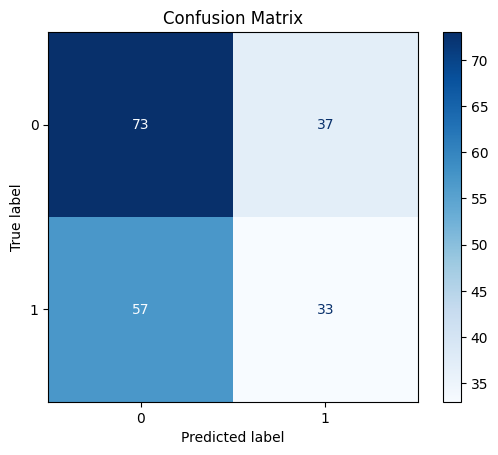


Accuracy : 0.53
Precision : 0.4714285714285714
Recall : 0.36666666666666664
F1 Score : 0.4125

Classification Report
              precision    recall  f1-score   support

           0       0.56      0.66      0.61       110
           1       0.47      0.37      0.41        90

    accuracy                           0.53       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.52      0.53      0.52       200



In [26]:

# Task 14: Evaluate Logistic Regression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix
cm = confusion_matrix(y_clf_test, y_pred)

print("Confusion Matrix")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Performance Metrics
accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred)
recall = recall_score(y_clf_test, y_pred)
f1 = f1_score(y_clf_test, y_pred)

print("\nAccuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_clf_test, y_pred))

AUC Score : 0.5275757575757576


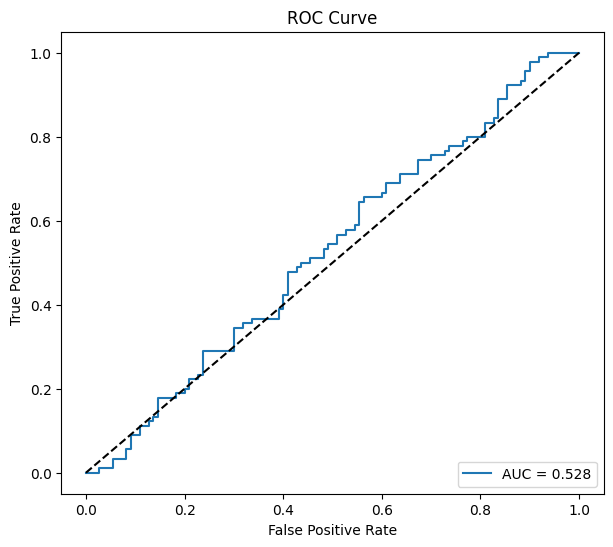

In [27]:

# Task 15: ROC Curve and AUC

from sklearn.metrics import roc_curve, roc_auc_score

# ROC values
fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob)

# AUC Score
auc = roc_auc_score(y_clf_test, y_prob)

print("AUC Score :", auc)

# Plot ROC Curve
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

In [28]:

# Task 16: Threshold Sensitivity

thresholds = [0.30,0.40,0.50,0.60,0.70]

results=[]

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_clf_test, predictions)
    recall = recall_score(y_clf_test, predictions)
    f1 = f1_score(y_clf_test, predictions)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_table = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(threshold_table)

   Threshold  Precision    Recall  F1 Score
0        0.3   0.450000  1.000000  0.620690
1        0.4   0.462857  0.900000  0.611321
2        0.5   0.471429  0.366667  0.412500
3        0.6   0.000000  0.000000  0.000000
4        0.7   0.000000  0.000000  0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:

# Task 17: Logistic Regression (C = 0.01)

strong_model = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

strong_model.fit(
    X_train_scaled,
    y_clf_train
)

# Predictions
strong_pred = strong_model.predict(X_test_scaled)

strong_prob = strong_model.predict_proba(
    X_test_scaled
)[:,1]

comparison = pd.DataFrame({

    "Model":[
        "C = 1.0",
        "C = 0.01"
    ],

    "Precision":[
        precision_score(y_clf_test,y_pred),
        precision_score(y_clf_test,strong_pred)
    ],

    "Recall":[
        recall_score(y_clf_test,y_pred),
        recall_score(y_clf_test,strong_pred)
    ],

    "AUC":[
        roc_auc_score(y_clf_test,y_prob),
        roc_auc_score(y_clf_test,strong_prob)
    ]

})

print(comparison)

      Model  Precision    Recall       AUC
0   C = 1.0   0.471429  0.366667  0.527576
1  C = 0.01   0.482143  0.300000  0.534141


In [30]:

# Task 18: Bootstrap Confidence Interval

auc_difference=[]

for i in range(500):

    sample_index = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_bootstrap = y_clf_test.iloc[sample_index]

    prob1 = y_prob[sample_index]

    prob2 = strong_prob[sample_index]

    auc1 = roc_auc_score(
        y_bootstrap,
        prob1
    )

    auc2 = roc_auc_score(
        y_bootstrap,
        prob2
    )

    auc_difference.append(
        auc1 - auc2
    )

mean_difference = np.mean(auc_difference)

lower = np.percentile(
    auc_difference,
    2.5
)

upper = np.percentile(
    auc_difference,
    97.5
)

print("Mean AUC Difference :", mean_difference)
print("95% Confidence Interval")
print("Lower Bound :", lower)
print("Upper Bound :", upper)

if lower > 0 or upper < 0:
    print("\nThe confidence interval excludes zero.")
    print("The C=1.0 model consistently outperforms the C=0.01 model.")
else:
    print("\nThe confidence interval includes zero.")
    print("The performance difference may not be statistically significant.")

Mean AUC Difference : -0.006529977741881549
95% Confidence Interval
Lower Bound : -0.02322696572683276
Upper Bound : 0.011543528677783995

The confidence interval includes zero.
The performance difference may not be statistically significant.
